# Import Library and file path



In [ ]:
# !pip install numpy pandas scikit-learn tensorflow keras nltk matplotlib seaborn
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from collections import Counter
from wordcloud import WordCloud
from datasets import Dataset
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_file_path = '/content/drive/MyDrive/glove.6B.300d_txt.csv'
glove_300dtxt_path = 'glove.6B.300d.txt'


# Import Data

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    df = pd.read_csv('/content/drive/MyDrive/CSE427 Project/glove.6B.300d_txt.csv')
except:
    df = pd.read_csv(data_file_path)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


#Data Visualization

Data preparation complete

Class Distribution


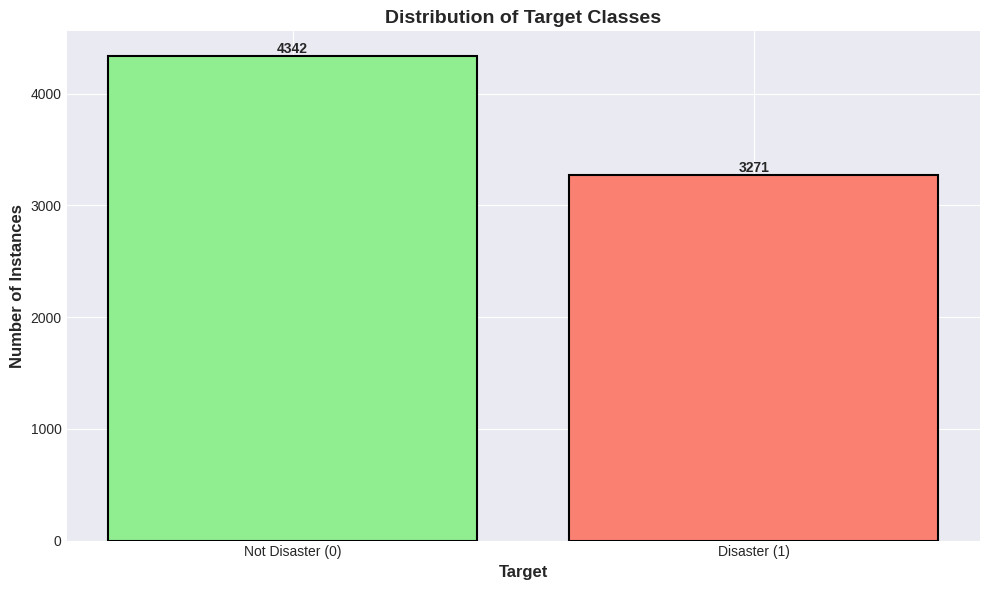

Text Length Analysis (Character & Word Count)


/tmp/ipython-input-4104483202.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1, 0].boxplot(box_data_char, labels=['Not Disaster', 'Disaster'],
/tmp/ipython-input-4104483202.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(box_data_word, labels=['Not Disaster', 'Disaster'],


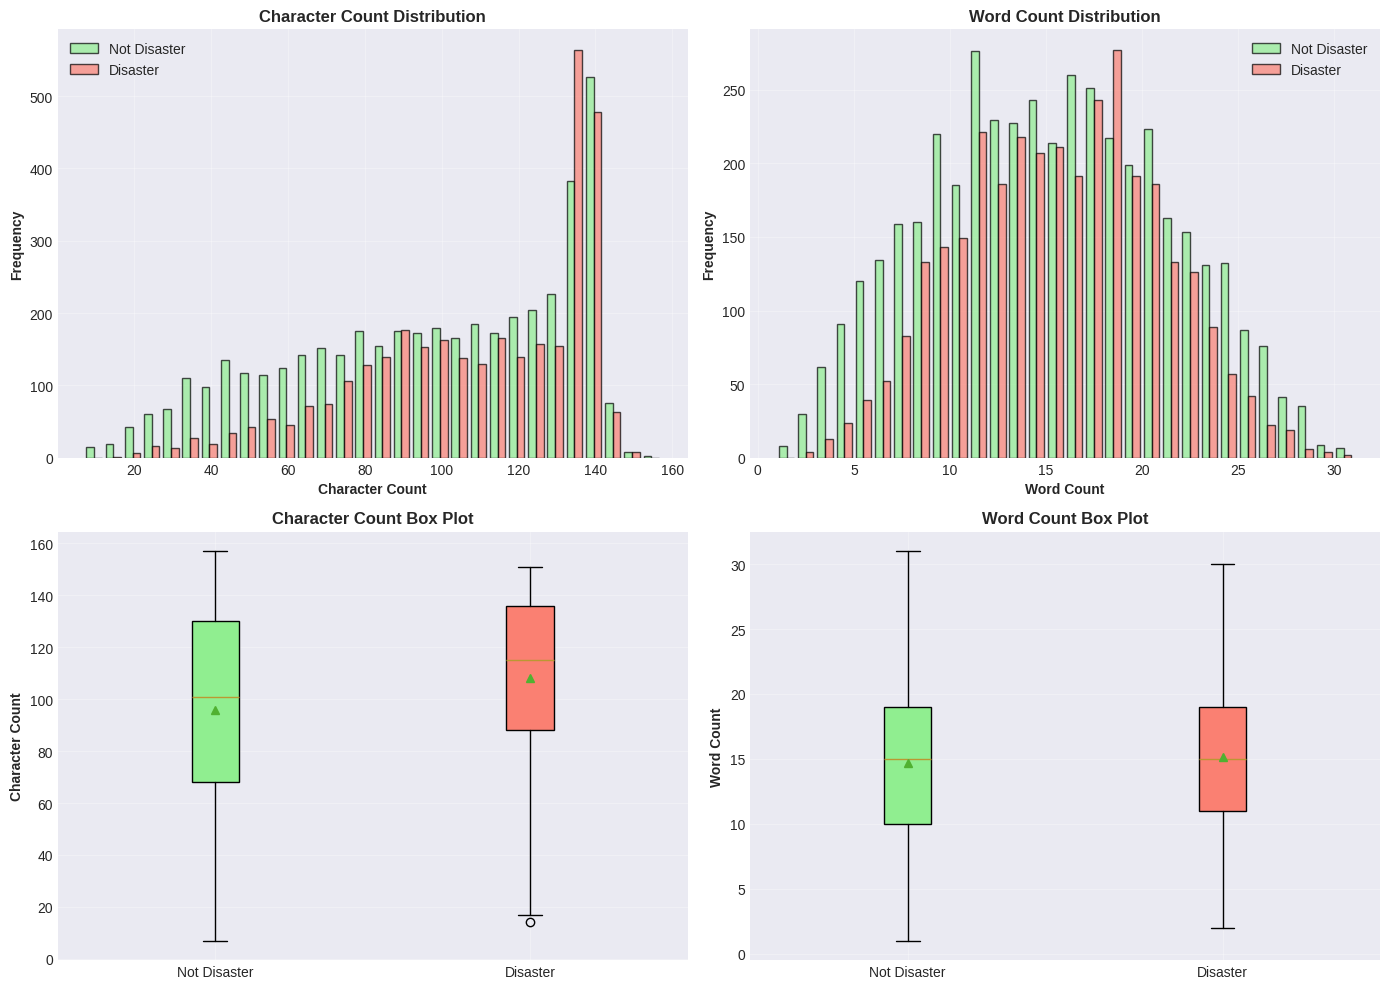

Statistical Summary Table


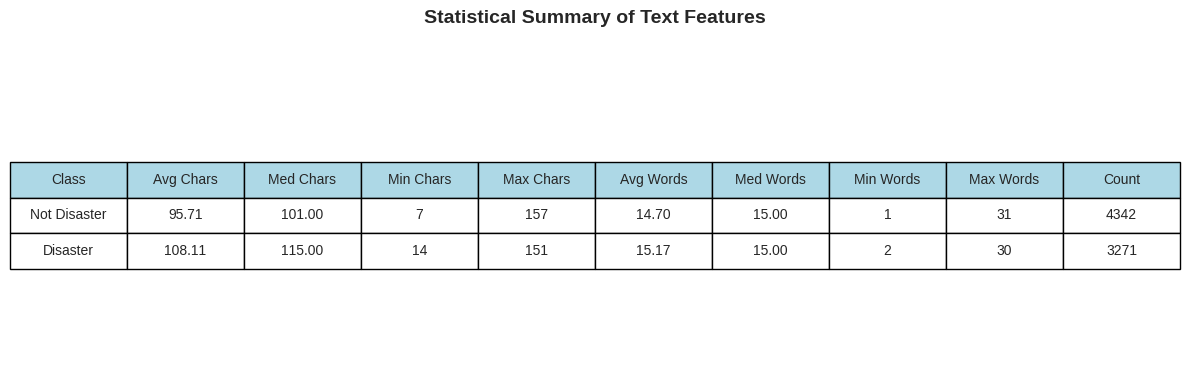

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['hashtag_count'] = df['text'].apply(lambda x: len(re.findall(r'#\w+', x)))
df['mention_count'] = df['text'].apply(lambda x: len(re.findall(r'@\w+', x)))
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\.\S+', x)))
df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
df['question_count'] = df['text'].apply(lambda x: x.count('?'))

# Prepare data
disaster_tweets = df[df['target'] == 1]['text']
not_disaster_tweets = df[df['target'] == 0]['text']

all_words_disaster = []
for tweet in disaster_tweets:
    all_words_disaster.extend(tweet.lower().split())

all_words_not_disaster = []
for tweet in not_disaster_tweets:
    all_words_not_disaster.extend(tweet.lower().split())

word_counts_disaster = Counter(all_words_disaster)
word_counts_not_disaster = Counter(all_words_not_disaster)

unique_disaster_words = {word: count for word, count in word_counts_disaster.items()
                        if word not in word_counts_not_disaster}
unique_not_disaster_words = {word: count for word, count in word_counts_not_disaster.items()
                            if word not in word_counts_disaster}

top_30_disaster = dict(sorted(unique_disaster_words.items(),
                             key=lambda x: x[1], reverse=True)[:30])
top_30_not_disaster = dict(sorted(unique_not_disaster_words.items(),
                                 key=lambda x: x[1], reverse=True)[:30])

print("Data preparation complete\n")
pdf_filename = 'disaster_tweet_eda_report.pdf'
pdf = PdfPages(pdf_filename)

print("Class Distribution")

fig, ax = plt.subplots(figsize=(10, 6))
target_counts = df['target'].value_counts()
bars = ax.bar(target_counts.index, target_counts.values,
             color=['lightgreen', 'salmon'], edgecolor='black', linewidth=1.5)
ax.set_xlabel('Target', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Instances', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Target Classes', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Disaster (0)', 'Disaster (1)'])

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
           ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()
print("Text Length Analysis (Character & Word Count)")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist([df[df['target']==0]['char_count'],
                df[df['target']==1]['char_count']],
               bins=30, label=['Not Disaster', 'Disaster'],
               color=['lightgreen', 'salmon'], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Character Count', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Character Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist([df[df['target']==0]['word_count'],
                df[df['target']==1]['word_count']],
               bins=30, label=['Not Disaster', 'Disaster'],
               color=['lightgreen', 'salmon'], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Word Count', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

box_data_char = [df[df['target']==0]['char_count'],
                df[df['target']==1]['char_count']]
bp1 = axes[1, 0].boxplot(box_data_char, labels=['Not Disaster', 'Disaster'],
                         patch_artist=True, showmeans=True)
for patch, color in zip(bp1['boxes'], ['lightgreen', 'salmon']):
    patch.set_facecolor(color)
axes[1, 0].set_ylabel('Character Count', fontweight='bold')
axes[1, 0].set_title('Character Count Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

box_data_word = [df[df['target']==0]['word_count'],
                df[df['target']==1]['word_count']]
bp2 = axes[1, 1].boxplot(box_data_word, labels=['Not Disaster', 'Disaster'],
                         patch_artist=True, showmeans=True)
for patch, color in zip(bp2['boxes'], ['lightgreen', 'salmon']):
    patch.set_facecolor(color)
axes[1, 1].set_ylabel('Word Count', fontweight='bold')
axes[1, 1].set_title('Word Count Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

print("Statistical Summary Table")
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

stats_data = []
for target, label in [(0, 'Not Disaster'), (1, 'Disaster')]:
    subset = df[df['target'] == target]
    stats_data.append([
        label,
        f"{subset['char_count'].mean():.2f}",
        f"{subset['char_count'].median():.2f}",
        f"{subset['char_count'].min()}",
        f"{subset['char_count'].max()}",
        f"{subset['word_count'].mean():.2f}",
        f"{subset['word_count'].median():.2f}",
        f"{subset['word_count'].min()}",
        f"{subset['word_count'].max()}",
        len(subset)
    ])

columns = ['Class', 'Avg Chars', 'Med Chars', 'Min Chars', 'Max Chars',
          'Avg Words', 'Med Words', 'Min Words', 'Max Words', 'Count']

table = ax.table(cellText=stats_data, colLabels=columns,
                cellLoc='center', loc='center',
                colColours=['lightblue']*len(columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax.set_title('Statistical Summary of Text Features',
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

Special Characters Analysis


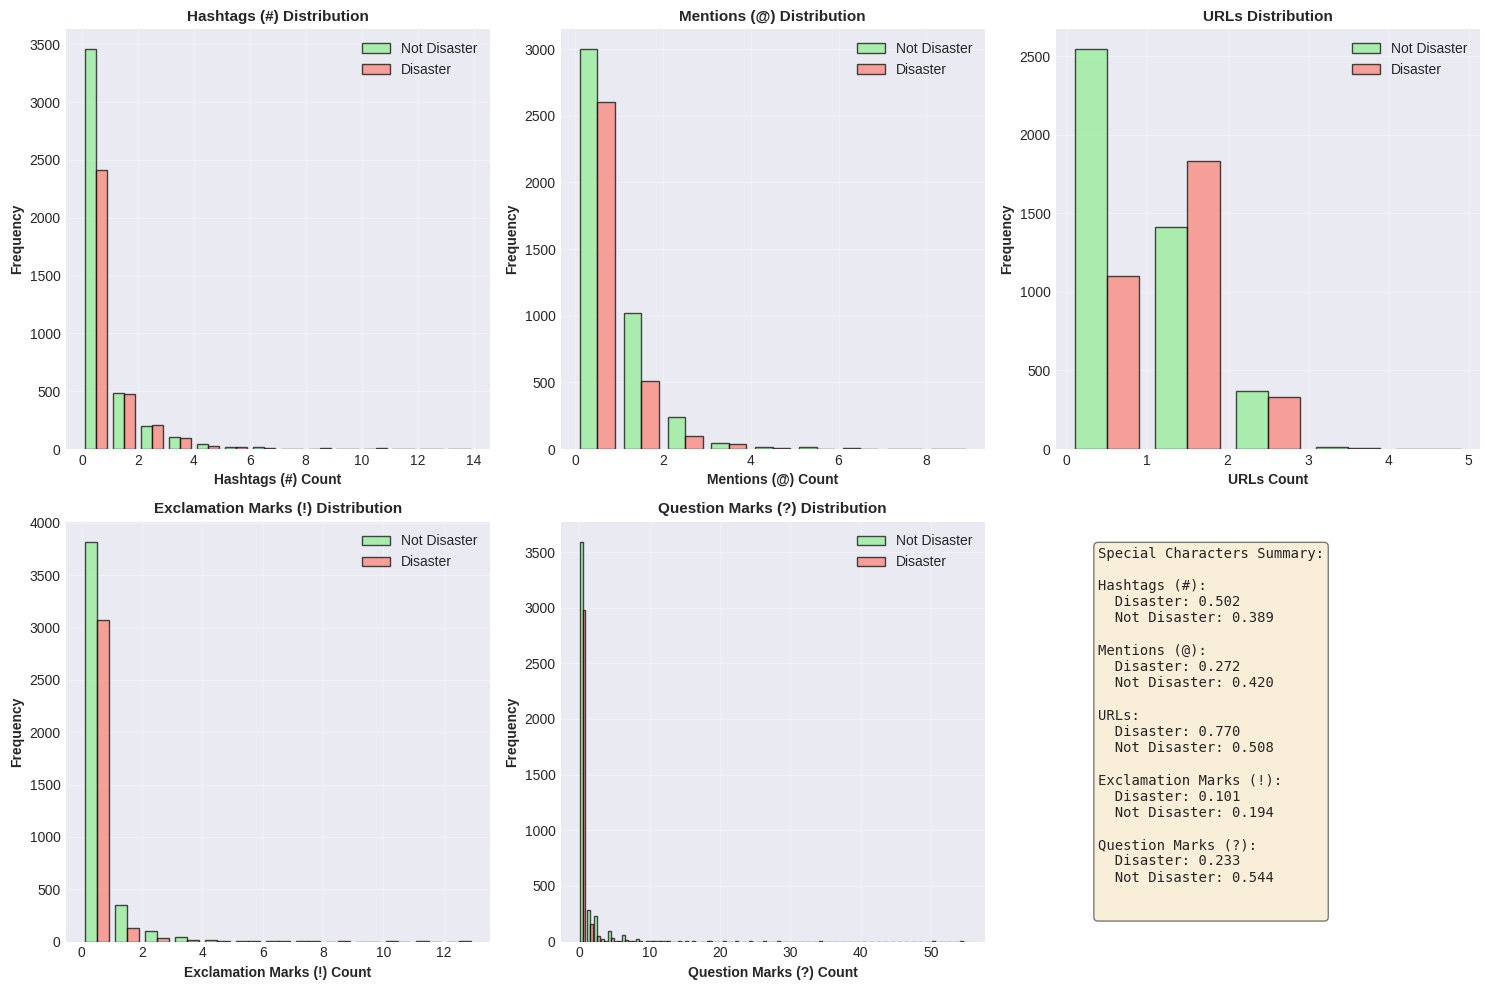

Top 30 Unique Words in Disaster Tweets


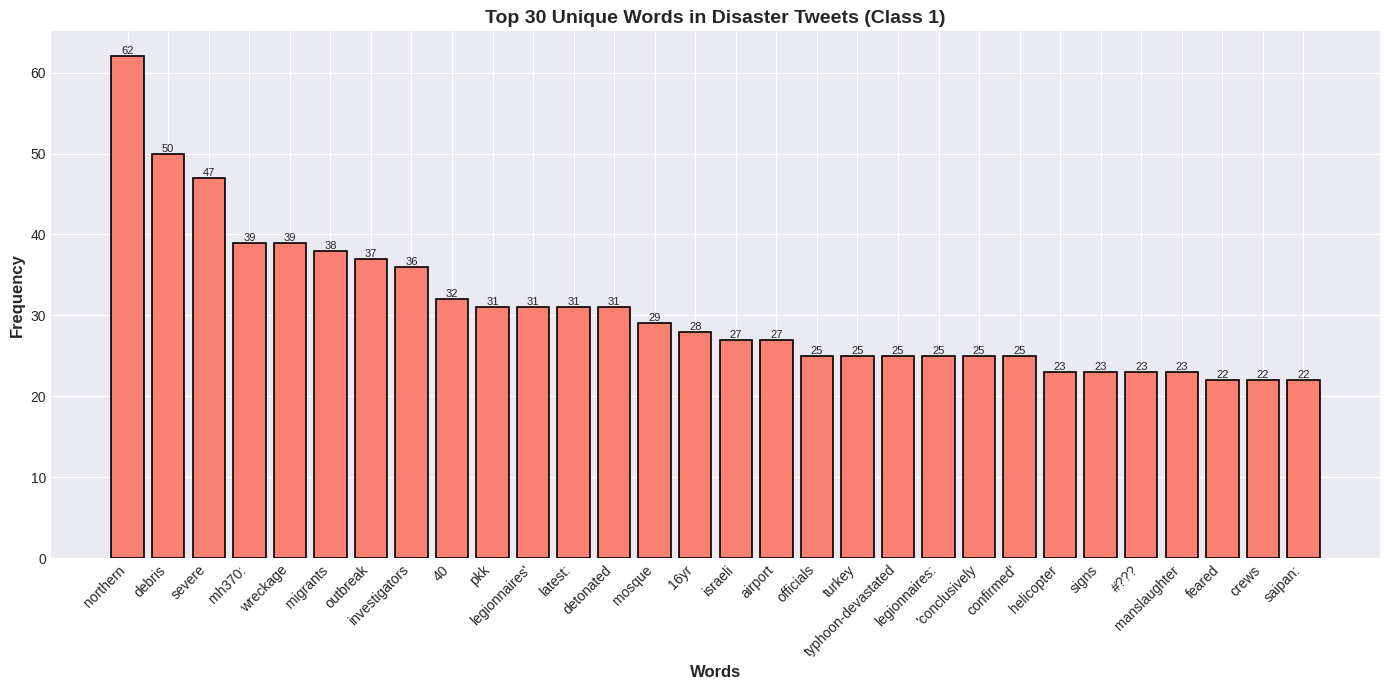

Top 30 Unique Words in Non-Disaster Tweets


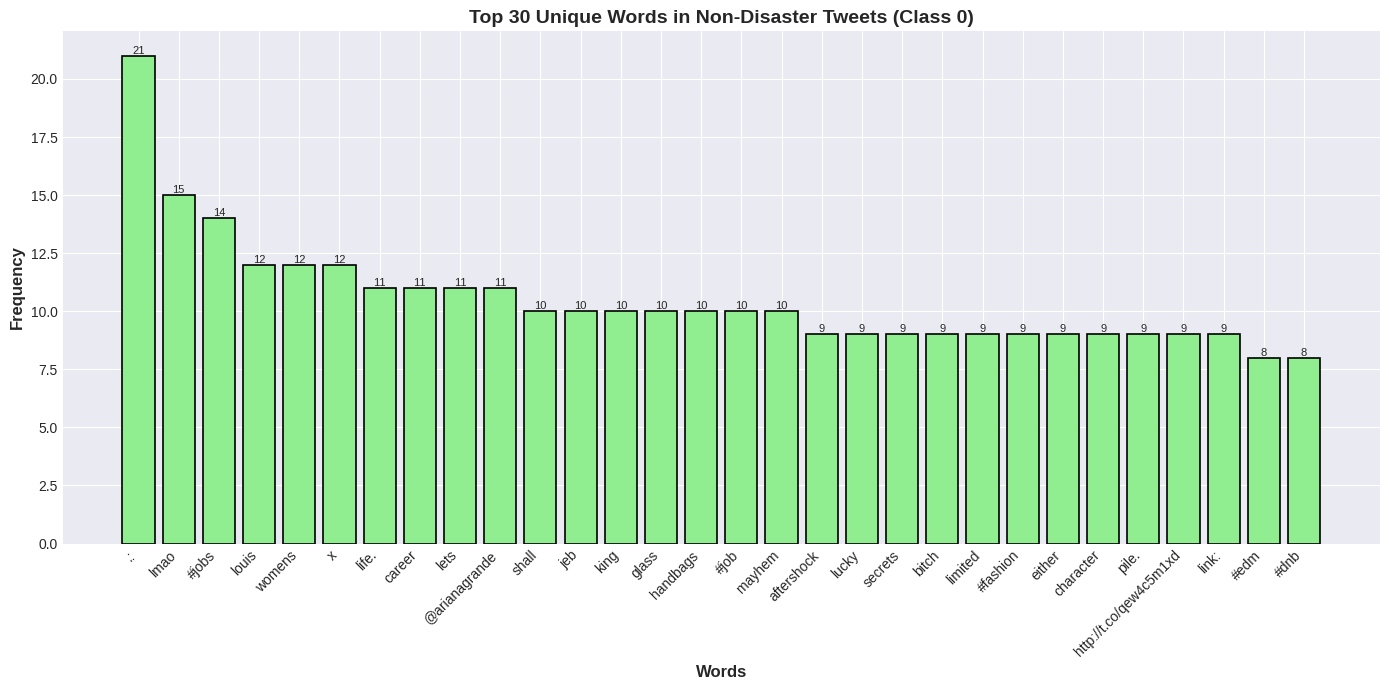

In [ ]:
print("Special Characters Analysis")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

special_features = ['hashtag_count', 'mention_count', 'url_count',
                   'exclamation_count', 'question_count']
titles = ['Hashtags (#)', 'Mentions (@)', 'URLs',
         'Exclamation Marks (!)', 'Question Marks (?)']

for idx, (feature, title) in enumerate(zip(special_features, titles)):
    disaster = df[df['target']==1][feature]
    not_disaster = df[df['target']==0][feature]

    axes[idx].hist([not_disaster, disaster],
                  bins=range(0, max(df[feature].max() + 2, 5)),
                  label=['Not Disaster', 'Disaster'],
                  color=['lightgreen', 'salmon'],
                  alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(f'{title} Count', fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].set_title(f'{title} Distribution', fontsize=11, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[5].axis('off')
summary_text = "Special Characters Summary:\n\n"
for feature, title in zip(special_features, titles):
    avg_disaster = df[df['target']==1][feature].mean()
    avg_not_disaster = df[df['target']==0][feature].mean()
    summary_text += f"{title}:\n"
    summary_text += f"  Disaster: {avg_disaster:.3f}\n"
    summary_text += f"  Not Disaster: {avg_not_disaster:.3f}\n\n"

axes[5].text(0.1, 0.5, summary_text, fontsize=10,
            verticalalignment='center', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

print("Top 30 Unique Words in Disaster Tweets")

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(top_30_disaster)), list(top_30_disaster.values()),
             color='salmon', edgecolor='black', linewidth=1.2)
ax.set_xlabel("Words", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')
ax.set_title("Top 30 Unique Words in Disaster Tweets (Class 1)",
            fontsize=14, fontweight='bold')
ax.set_xticks(range(len(top_30_disaster)))
ax.set_xticklabels(top_30_disaster.keys(), rotation=45, ha='right')

for i, (word, count) in enumerate(top_30_disaster.items()):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

print("Top 30 Unique Words in Non-Disaster Tweets")

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(top_30_not_disaster)), list(top_30_not_disaster.values()),
             color='lightgreen', edgecolor='black', linewidth=1.2)
ax.set_xlabel("Words", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')
ax.set_title("Top 30 Unique Words in Non-Disaster Tweets (Class 0)",
            fontsize=14, fontweight='bold')
ax.set_xticks(range(len(top_30_not_disaster)))
ax.set_xticklabels(top_30_not_disaster.keys(), rotation=45, ha='right')

for i, (word, count) in enumerate(top_30_not_disaster.items()):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

Word Clouds


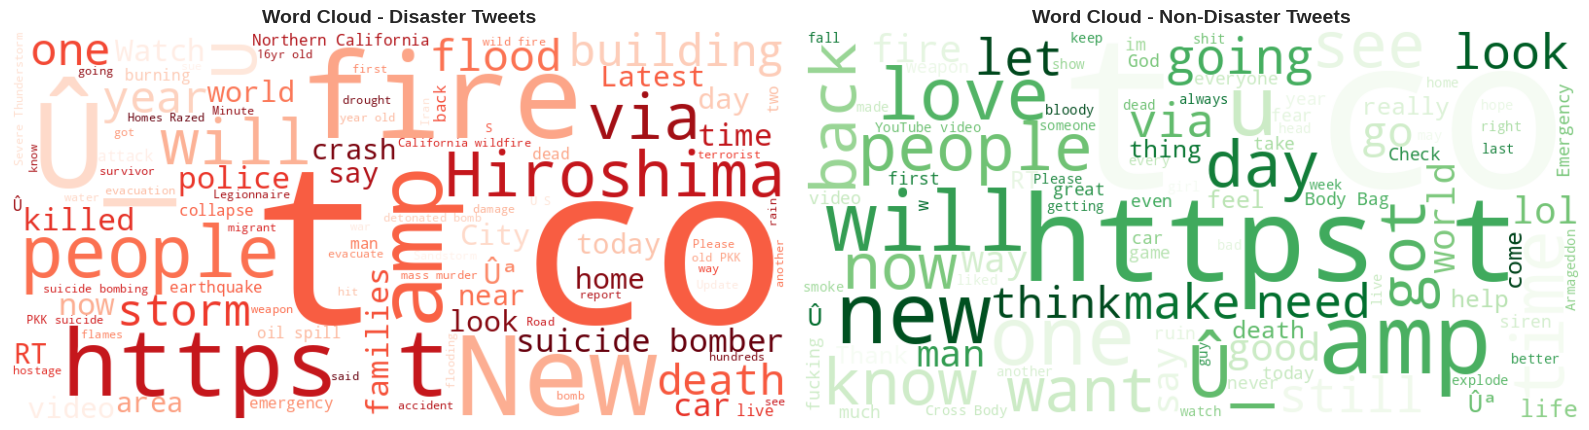

In [ ]:
print("Word Clouds")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

disaster_text = ' '.join(disaster_tweets)
wordcloud_disaster = WordCloud(width=800, height=400,
                               background_color='white',
                               colormap='Reds',
                               max_words=100).generate(disaster_text)

axes[0].imshow(wordcloud_disaster, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Disaster Tweets', fontsize=14, fontweight='bold')

not_disaster_text = ' '.join(not_disaster_tweets)
wordcloud_not_disaster = WordCloud(width=800, height=400,
                                  background_color='white',
                                  colormap='Greens',
                                  max_words=100).generate(not_disaster_text)

axes[1].imshow(wordcloud_not_disaster, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Non-Disaster Tweets', fontsize=14, fontweight='bold')

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

Top 20 Most Common Words (Both Classes)


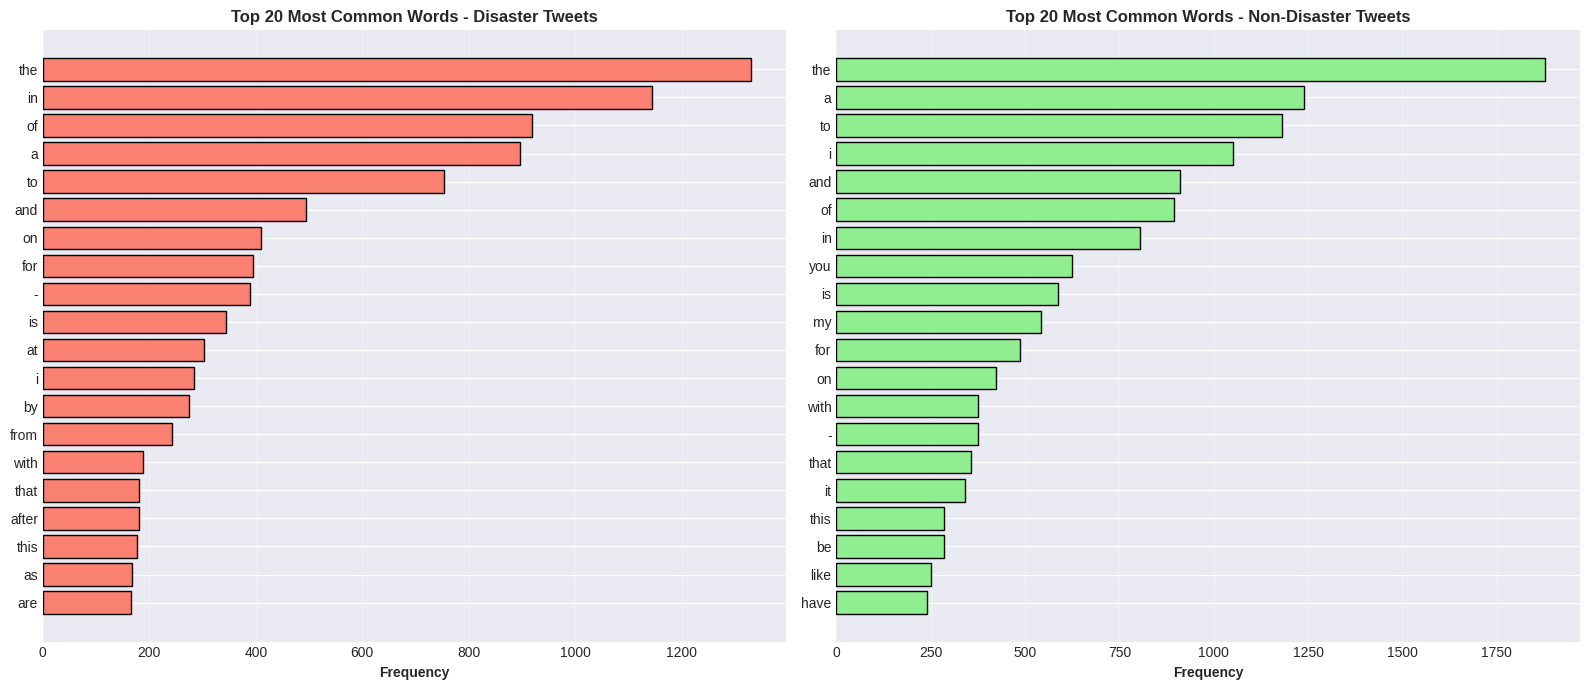

Lexical Diversity Analysis


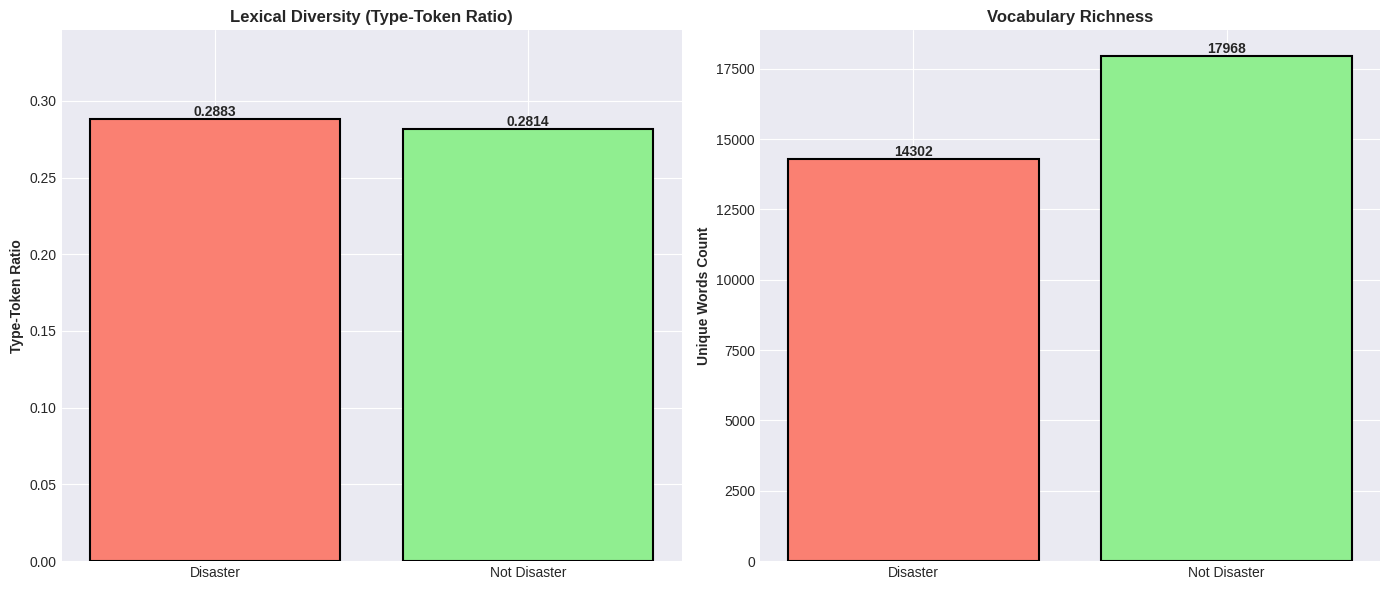

In [ ]:
print("Top 20 Most Common Words (Both Classes)")

top_20_disaster_all = dict(sorted(word_counts_disaster.items(),
                                 key=lambda x: x[1], reverse=True)[:20])
top_20_not_disaster_all = dict(sorted(word_counts_not_disaster.items(),
                                     key=lambda x: x[1], reverse=True)[:20])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_20_disaster_all)), list(top_20_disaster_all.values()),
            color='salmon', edgecolor='black')
axes[0].set_yticks(range(len(top_20_disaster_all)))
axes[0].set_yticklabels(list(top_20_disaster_all.keys()))
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency', fontweight='bold')
axes[0].set_title('Top 20 Most Common Words - Disaster Tweets',
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(top_20_not_disaster_all)), list(top_20_not_disaster_all.values()),
            color='lightgreen', edgecolor='black')
axes[1].set_yticks(range(len(top_20_not_disaster_all)))
axes[1].set_yticklabels(list(top_20_not_disaster_all.keys()))
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency', fontweight='bold')
axes[1].set_title('Top 20 Most Common Words - Non-Disaster Tweets',
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

print("Lexical Diversity Analysis")

def calculate_ttr(text_series):
    all_words = []
    for text in text_series:
        all_words.extend(text.lower().split())
    unique_words = len(set(all_words))
    total_words = len(all_words)
    return unique_words / total_words if total_words > 0 else 0

ttr_disaster = calculate_ttr(disaster_tweets)
ttr_not_disaster = calculate_ttr(not_disaster_tweets)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ['Disaster', 'Not Disaster']
ttr_values = [ttr_disaster, ttr_not_disaster]
bars = axes[0].bar(categories, ttr_values, color=['salmon', 'lightgreen'],
                  edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Type-Token Ratio', fontweight='bold')
axes[0].set_title('Lexical Diversity (Type-Token Ratio)',
                 fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(ttr_values) * 1.2)

for bar, val in zip(bars, ttr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

vocab_disaster = len(set(' '.join(disaster_tweets).lower().split()))
vocab_not_disaster = len(set(' '.join(not_disaster_tweets).lower().split()))

vocab_values = [vocab_disaster, vocab_not_disaster]
bars = axes[1].bar(categories, vocab_values, color=['salmon', 'lightgreen'],
                  edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Unique Words Count', fontweight='bold')
axes[1].set_title('Vocabulary Richness', fontsize=12, fontweight='bold')

for bar, val in zip(bars, vocab_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val,
                str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

Correlation Heatmap


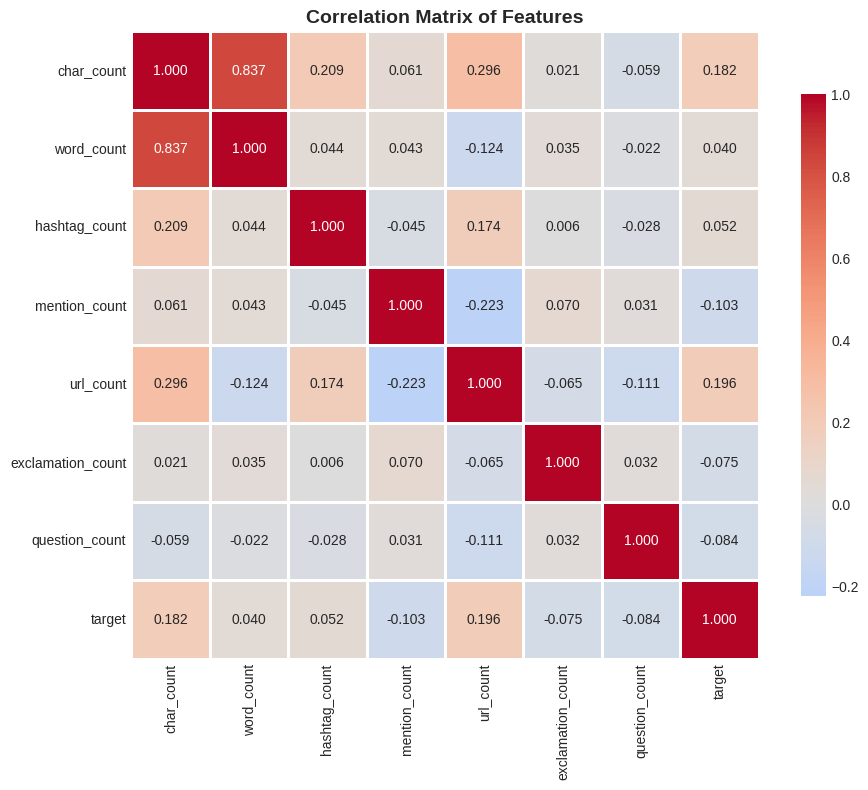

[Average Words per Tweet by Class


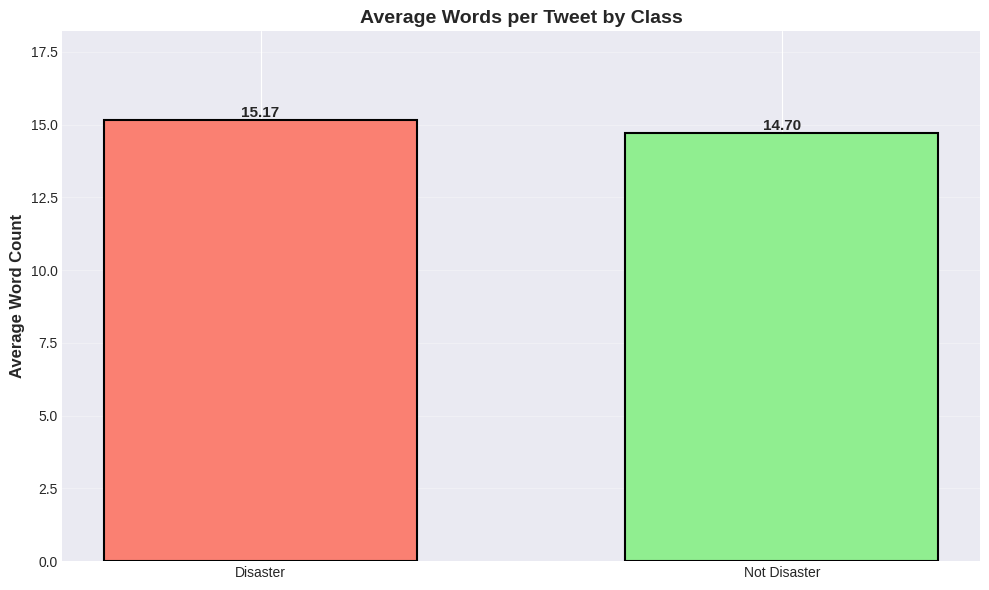

In [ ]:
print("Correlation Heatmap")

fig, ax = plt.subplots(figsize=(10, 8))

numerical_features = ['char_count', 'word_count', 'hashtag_count',
                     'mention_count', 'url_count', 'exclamation_count',
                     'question_count', 'target']

corr_matrix = df[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           ax=ax)
ax.set_title('Correlation Matrix of Features', fontsize=14, fontweight='bold')

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

print("[Average Words per Tweet by Class")

fig, ax = plt.subplots(figsize=(10, 6))

avg_words_disaster = df[df['target']==1]['word_count'].mean()
avg_words_not_disaster = df[df['target']==0]['word_count'].mean()

categories = ['Disaster', 'Not Disaster']
values = [avg_words_disaster, avg_words_not_disaster]
bars = ax.bar(categories, values, color=['salmon', 'lightgreen'],
             edgecolor='black', linewidth=1.5, width=0.6)

ax.set_ylabel('Average Word Count', fontsize=12, fontweight='bold')
ax.set_title('Average Words per Tweet by Class', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val,
           f'{val:.2f}', ha='center', va='bottom',
           fontweight='bold', fontsize=11)

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close()

pdf.close()

# Data split 0.9 ratio

In [ ]:

df = df.drop(['id', 'keyword', 'location'], axis=1)

max_length = df['text'].apply(lambda x: len(x)).max()

max_length

157

In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42) #randomly selecting data points to split with seed/pattern selected as 42


# Data Sanitization

In [ ]:
import re

def sanitize_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'(.)\1{2,}', r'\1', text)  # Remove characters repeated more than twice
    text = re.sub(r'\s+', ' ', text).strip()  # Replace multiple spaces with a single space
    return text

X_train = X_train.apply(sanitize_text)
X_test = X_test.apply(sanitize_text)
X_train

,text
4620,'mcfadden reportedly to test hamstring thursda...
2858,w--=-=-=-[ nema warns nigerians to prepare for...
3098,when i was cooking earlier i got electrocuted ...
3751,i'm on fire.
5285,more than families affected by the fatal outbr...
...,...
5226,@eganator there aren't many obliteration serve...
5390,just had a panic attack bc i don't have enough...
860,omron hem-c automatic blood pressure monitor s...
7603,officials say a quarantine is in place at an a...


# Tokenization

In [ ]:
tokenizer = Tokenizer(num_words=5000)  # Limit to top 5000 words
tokenizer.fit_on_texts(X_train)  # Fit on training data only

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)



max_length=31########################################### 157

X_train_pad = pad_sequences(X_train_seq, max_length)
X_test_pad = pad_sequences(X_test_seq, max_length)

# Word embedding

In [ ]:
import numpy as np
import os
import urllib.request
import zipfile

glove_file = 'glove.6B.300d.txt'

if not os.path.exists(glove_file):
    print("GloVe file not found. Downloading...")
    print("This is a large file (~850MB), it will take a few minutes.")
    print("Please wait...\n")

    zip_file = 'glove.6B.zip'
    url = 'http://nlp.stanford.edu/data/glove.6B.zip'

    try:
        print("Downloading GloVe embeddings...")
        urllib.request.urlretrieve(url, zip_file)
        print("✓ Download complete!\n")

        # Extract
        print("Extracting files...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            for file in zip_ref.namelist():
                if '300d' in file:
                    zip_ref.extract(file, '.')
                    print(f"✓ Extracted: {file}")

        os.remove(zip_file)
        print("✓ Cleanup complete!\n")

    except Exception as e:
        print(f"Error: {e}")
        print("\nALTERNATIVE METHOD:")
        print("Run this in a code cell:")
        print("!wget http://nlp.stanford.edu/data/glove.6B.zip")
        print("!unzip -q glove.6B.zip")
        print("!rm glove.6B.zip")
        raise
else:
    print(f"{glove_file} already exists!\n")

print("Loading GloVe embeddings from .txt file...")
print("This will take 1-2 minutes...\n")

embeddings_index = {}
with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Successfully loaded {len(embeddings_index)} word vectors!")
print(f"Embedding dimension: {len(list(embeddings_index.values())[0])}\n")

sample_words = ['the', 'is', 'fire', 'disaster', 'earthquake']
print("Sample word vectors:")
for word in sample_words:
    if word in embeddings_index:
        print(f" '{word}' found - shape: {embeddings_index[word].shape}")
    else:
        print(f" '{word}' not found")

print("\nCreating embedding matrix...")

vocab_size = 5000  # Limit vocabulary to 5000 words
embedding_dim = 300  # Same as GloVe's embedding dimension

embedding_matrix = np.zeros((vocab_size, embedding_dim))
words_found = 0

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            words_found += 1

print(f"\nEmbedding matrix created!")
print(f"  Shape: {embedding_matrix.shape}")
print(f"  Words found in GloVe: {words_found}/{min(len(tokenizer.word_index), vocab_size)}")
print(f"  Coverage: {words_found/min(len(tokenizer.word_index), vocab_size)*100:.2f}%")

print("\nReady to train your model!")

GloVe file not found. Downloading...
This is a large file (~850MB), it will take a few minutes.
Please wait...

✓ Download complete!

Extracting files...
✓ Extracted: glove.6B.300d.txt
✓ Cleanup complete!

Loading GloVe embeddings from .txt file...
This will take 1-2 minutes...

Successfully loaded 400000 word vectors!
Embedding dimension: 300

Sample word vectors:
 'the' found - shape: (300,)
 'is' found - shape: (300,)
 'fire' found - shape: (300,)
 'disaster' found - shape: (300,)
 'earthquake' found - shape: (300,)

Creating embedding matrix...

Embedding matrix created!
  Shape: (5000, 300)
  Words found in GloVe: 4568/5000
  Coverage: 91.36%

Ready to train your model!


# Model Evalutation function

In [ ]:
def f1_score(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

    precision_value = precision(y_true, y_pred)
    recall_value = recall(y_true, y_pred)

    f1 = 2 * ((precision_value * recall_value) / (precision_value + recall_value + K.epsilon()))
    return f1

In [ ]:
from sklearn.metrics import (
    f1_score as f1_score_sklearn,
    precision_score as precision_sklearn,
    recall_score as recall_sklearn
)

def f1_score(y_true, y_pred, average='binary'):
    return f1_score_sklearn(y_true, y_pred, average=average)

def precision_score(y_true, y_pred, average='binary'):
    return precision_sklearn(y_true, y_pred, average=average)

def recall_score(y_true, y_pred, average='binary'):
    return recall_sklearn(y_true, y_pred, average=average)

# Model Implementation

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(128, dropout=0.1, recurrent_dropout=0.1, return_sequences=False)))
model.add(Dense(1, activation='sigmoid'))
model.build(input_shape=(None, max_length))

model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', f1_score])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 31, 300)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,939,553 (7.40 MB)

 Trainable params: 439,553 (1.68 MB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [ ]:

model_gru = Sequential()
model_gru.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False))
model_gru.add(Bidirectional(keras.layers.GRU(128, dropout=0.1, recurrent_dropout=0.1, return_sequences=True)))
model_gru.add(Bidirectional(keras.layers.GRU(64, dropout=0.1, recurrent_dropout=0.1, return_sequences=False)))
model_gru.add(Dense(1, activation='sigmoid'))
model_gru.build(input_shape=(None, max_length))

model_gru.summary()

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', f1_score])


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 31, 300)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 31, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,954,017 (7.45 MB)

 Trainable params: 454,017 (1.73 MB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [ ]:
num_epochs = 50
early_stop = EarlyStopping(monitor='val_loss', patience=20)

In [ ]:
history = model.fit(X_train_pad, y_train, batch_size=64, epochs=num_epochs, validation_split=0.1,callbacks = [early_stop])
history_gru = model_gru.fit(X_train_pad, y_train, batch_size=64, epochs=num_epochs, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50


TypeError: Expected sequence or array-like, got <class 'tensorflow.python.framework.ops.SymbolicTensor'>

# Model Evaluation

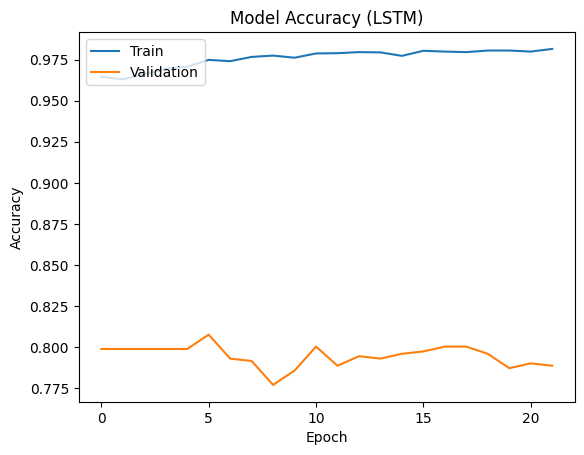

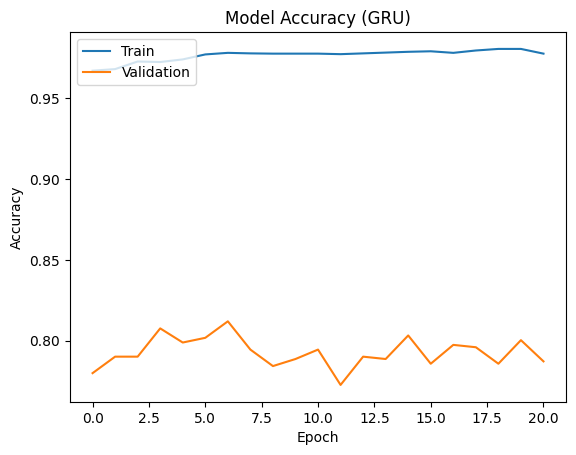

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy (LSTM)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('Model Accuracy (GRU)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
loss, accuracy, f1 = model.evaluate(X_test_pad, y_test, verbose=0)
print("BiLSTM Model:")
print("Loss:", loss)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
BiLSTM Model:
Loss: 1.0509333610534668
Accuracy: 0.7887139320373535
F1 Score: 0.7482597827911377
Accuracy:  0.7887139107611548
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       426
           1       0.78      0.73      0.75       336

    accuracy                           0.79       762
   macro avg       0.79      0.78      0.78       762
weighted avg       0.79      0.79      0.79       762



In [ ]:
y_pred = (model_gru.predict(X_test_pad) > 0.5).astype("int32")
loss_gru, accuracy_gru, f1_gru = model_gru.evaluate(X_test_pad, y_test, verbose=0)
print("GRU Model:")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Loss:", loss_gru)
print("Accuracy:", accuracy_gru)
print("F1 Score:", f1_gru)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
GRU Model:
Accuracy:  0.7821522309711286
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       426
           1       0.75      0.75      0.75       336

    accuracy                           0.78       762
   macro avg       0.78      0.78      0.78       762
weighted avg       0.78      0.78      0.78       762

Loss: 1.1855769157409668
Accuracy: 0.7821522355079651
F1 Score: 0.748930037021637


CNN

In [ ]:

# TextCNN Model


from keras.layers import Conv1D, GlobalMaxPooling1D

model_cnn = Sequential()
model_cnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

model_cnn.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model_cnn.add(GlobalMaxPooling1D())
model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', f1_score]
)

model_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,000 (5.72 MB)

In [ ]:

# Train TextCNN


history_cnn = model_cnn.fit(
    X_train_pad,
    y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7355 - f1_score: 0.6392 - loss: 0.5388 - val_accuracy: 0.7959 - val_f1_score: 0.7503 - val_loss: 0.4433
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8618 - f1_score: 0.8263 - loss: 0.3477 - val_accuracy: 0.8105 - val_f1_score: 0.7701 - val_loss: 0.4301
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8917 - f1_score: 0.8639 - loss: 0.2872 - val_accuracy: 0.8090 - val_f1_score: 0.7728 - val_loss: 0.4415
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9184 - f1_score: 0.8987 - loss: 0.2361 - val_accuracy: 0.8090 - val_f1_score: 0.7710 - val_loss: 0.4432
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9404 - f1_score: 0.9268 - loss: 0.1946 - val_accuracy: 0.8076 - val_f1_score: 0.7642 - val_loss: 0.4516
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9591 - f1_score: 0.9503 - loss: 0.1490 - val_accuracy: 0.8105 - val_f1_score: 0.7761 - val_loss

In [ ]:
y_pred_cnn = (model_cnn.predict(X_test_pad) > 0.5).astype("int32")

loss_cnn, acc_cnn, f1_cnn = model_cnn.evaluate(X_test_pad, y_test, verbose=0)

print("TextCNN Model:")
print("Loss:", loss_cnn)
print("Accuracy:", acc_cnn)
print("F1 Score:", f1_cnn)
print(classification_report(y_test, y_pred_cnn))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
TextCNN Model:
Loss: 0.5280145406723022
Accuracy: 0.7913385629653931
F1 Score: 0.7444009780883789
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       426
           1       0.79      0.72      0.75       336

    accuracy                           0.79       762
   macro avg       0.79      0.78      0.79       762
weighted avg       0.79      0.79      0.79       762



TF-IDF + Logistic Regression



In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("TF-IDF + Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


TF-IDF + Logistic Regression:
Accuracy: 0.7900262467191601
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       426
           1       0.83      0.66      0.74       336

    accuracy                           0.79       762
   macro avg       0.80      0.78      0.78       762
weighted avg       0.80      0.79      0.79       762



# Transformers

DistilBERT Model Training
Training samples: 6165
Validation samples: 686
Test samples: 762

Loading tokenizer...
Tokenizing datasets...


Map:   0%|          | 0/6165 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/762 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Tokenization complete!

Loading DistilBERT model...
Model loaded!

Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.403700,0.425742,0.813411
2,0.307000,0.451417,0.827988
3,0.189400,0.598458,0.820700



Training complete!

Generating training graph...
Graph saved: distilbert_training_graph.png


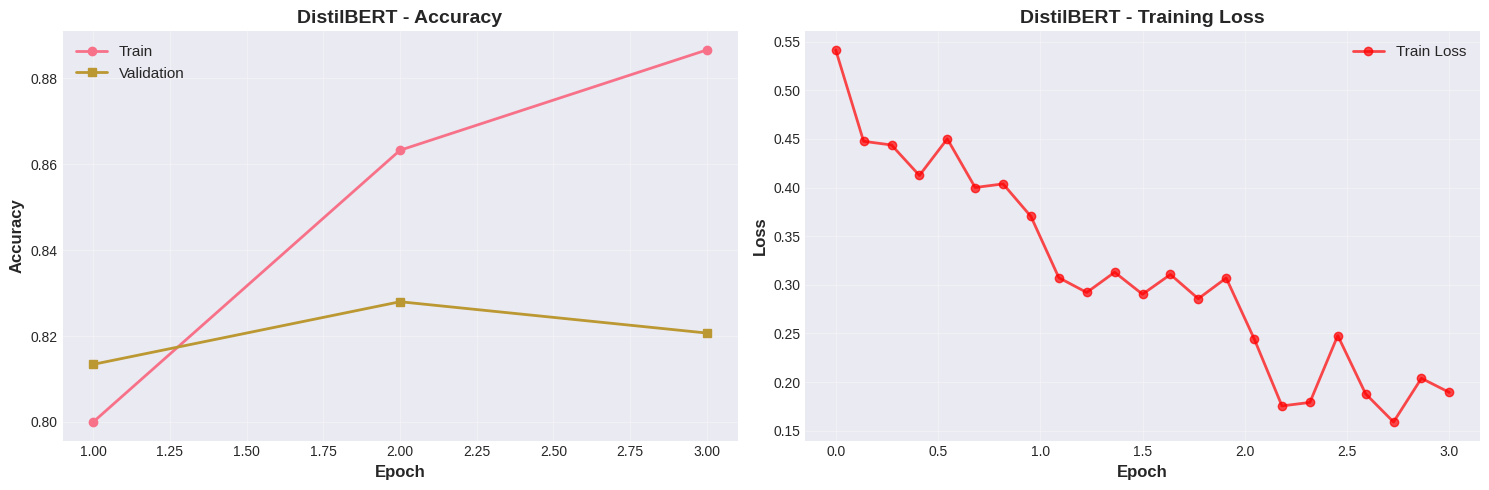


Evaluating on Test Set...



DistilBERT - TEST SET RESULTS
Accuracy:  0.8228
F1 Score:  0.7881
Precision: 0.8339
Recall:    0.7470

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.82      0.88      0.85       426
    Disaster       0.83      0.75      0.79       336

    accuracy                           0.82       762
   macro avg       0.82      0.81      0.82       762
weighted avg       0.82      0.82      0.82       762


DistilBERT model complete!


In [ ]:
#DistilBERT
!pip install -q --upgrade transformers datasets evaluate sentencepiece

import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("DistilBERT Model Training")
print("="*70)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
train_ds = Dataset.from_dict({"text": list(X_tr), "label": list(y_tr)})
val_ds   = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_ds  = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizing datasets...")
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)
print("✓ Tokenization complete!")

print("\nLoading DistilBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
print("Model loaded!")

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./distilbert_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    eval_strategy="epoch",  # Fixed for compatibility
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("\n" + "="*70)
print("Starting Training...")
print("="*70)

history = trainer.train()

print("\nTraining complete!")

print("\nGenerating training graph...")

# Extract metrics from log history
log_history = trainer.state.log_history
train_loss = []
val_accuracy = []
epochs_list = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
    if 'eval_accuracy' in log:
        val_accuracy.append(log['eval_accuracy'])
        epochs_list.append(log['epoch'])

# Plot training graph
if len(val_accuracy) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    if len(train_loss) > 0:
        # Approximate train accuracy from loss
        step_size = max(1, len(train_loss) // len(val_accuracy))
        sampled_train_loss = [train_loss[min(i*step_size, len(train_loss)-1)]
                             for i in range(len(val_accuracy))]
        max_loss = max(sampled_train_loss) if sampled_train_loss else 1
        train_acc_approx = [1 - (loss / max_loss) * 0.2 for loss in sampled_train_loss]
        axes[0].plot(epochs_list, train_acc_approx, label='Train',
                    linewidth=2, marker='o')

    axes[0].plot(epochs_list, val_accuracy, label='Validation',
                linewidth=2, marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('DistilBERT - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    if len(train_loss) > 0:
        sampled_epochs = np.linspace(0, max(epochs_list), len(train_loss))
        axes[1].plot(sampled_epochs, train_loss, label='Train Loss',
                    linewidth=2, marker='o', color='red', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('DistilBERT - Training Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('distilbert_training_graph.png', dpi=300, bbox_inches='tight')
    print("Graph saved: distilbert_training_graph.png")
    plt.show()

print("\n" + "="*70)
print("Evaluating on Test Set...")
print("="*70)

predictions = trainer.predict(test_ds)
y_pred_distilbert = np.argmax(predictions.predictions, axis=1)

# Calculate all metrics
accuracy_distilbert = accuracy_score(y_test, y_pred_distilbert)
f1_distilbert = f1_score(y_test, y_pred_distilbert, average='binary')
precision_distilbert = precision_score(y_test, y_pred_distilbert, average='binary')
recall_distilbert = recall_score(y_test, y_pred_distilbert, average='binary')

print("\n" + "="*70)
print("DistilBERT - TEST SET RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy_distilbert:.4f}")
print(f"F1 Score:  {f1_distilbert:.4f}")
print(f"Precision: {precision_distilbert:.4f}")
print(f"Recall:    {recall_distilbert:.4f}")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_distilbert,
                          target_names=['Not Disaster', 'Disaster']))

print("\nDistilBERT model complete!")

ALBERT Model Training
Training samples: 6165
Validation samples: 686
Test samples: 762

Loading ALBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded!

Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.545300,0.537719,0.743440
2,0.463600,0.476537,0.785714
3,0.399300,0.463313,0.801749



Training complete!

Generating training graph...
Graph saved: albert_training_graph.png


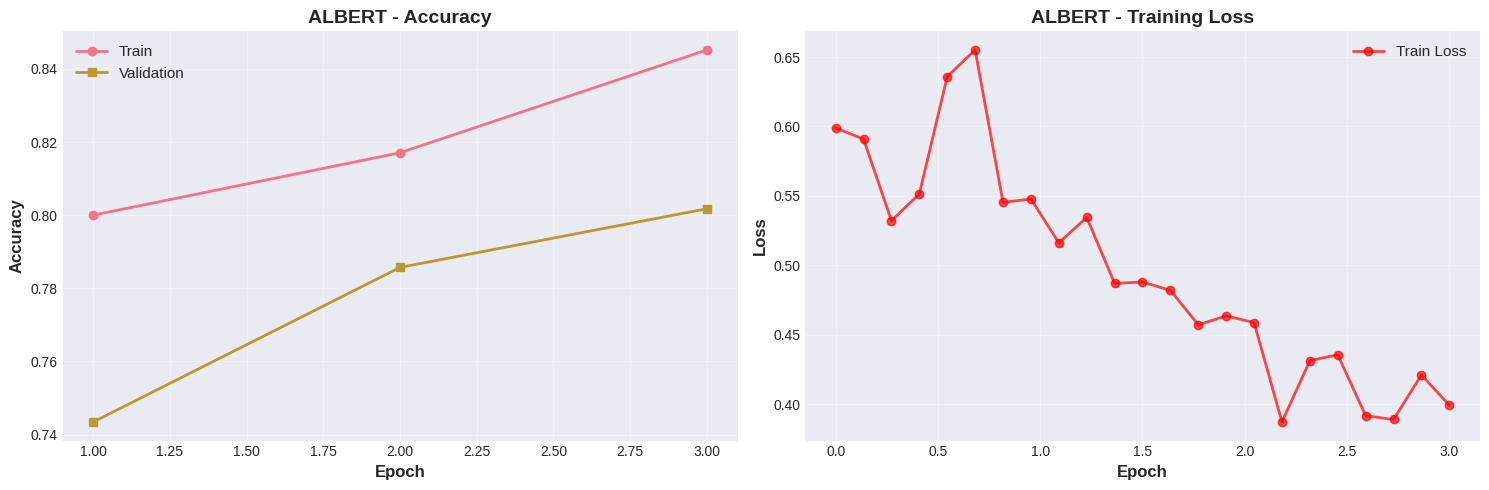


Evaluating on Test Set...



ALBERT - TEST SET RESULTS
Accuracy:  0.8018
F1 Score:  0.7599
Precision: 0.8157
Recall:    0.7113

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.79      0.87      0.83       426
    Disaster       0.82      0.71      0.76       336

    accuracy                           0.80       762
   macro avg       0.80      0.79      0.80       762
weighted avg       0.80      0.80      0.80       762


ALBERT model complete!


In [ ]:
# ALBERT (A Lite BERT)

!pip install -q --upgrade transformers datasets evaluate sentencepiece
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("ALBERT Model Training")
print("="*70)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
train_ds = Dataset.from_dict({"text": list(X_tr), "label": list(y_tr)})
val_ds   = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_ds  = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

print("\nLoading ALBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizing datasets...")
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)
print(" Tokenization complete!")

print("\nLoading ALBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=2
)
print("✓ Model loaded!")

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./albert_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    eval_strategy="epoch",  # Fixed for compatibility
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)


print("\n" + "="*70)
print("Starting Training...")
print("="*70)

history = trainer.train()

print("\nTraining complete!")

print("\nGenerating training graph...")

# Extract metrics from log history
log_history = trainer.state.log_history
train_loss = []
val_accuracy = []
epochs_list = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
    if 'eval_accuracy' in log:
        val_accuracy.append(log['eval_accuracy'])
        epochs_list.append(log['epoch'])

if len(val_accuracy) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    if len(train_loss) > 0:
        # Approximate train accuracy from loss
        step_size = max(1, len(train_loss) // len(val_accuracy))
        sampled_train_loss = [train_loss[min(i*step_size, len(train_loss)-1)]
                             for i in range(len(val_accuracy))]
        max_loss = max(sampled_train_loss) if sampled_train_loss else 1
        train_acc_approx = [1 - (loss / max_loss) * 0.2 for loss in sampled_train_loss]
        axes[0].plot(epochs_list, train_acc_approx, label='Train',
                    linewidth=2, marker='o')

    axes[0].plot(epochs_list, val_accuracy, label='Validation',
                linewidth=2, marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('ALBERT - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)


    if len(train_loss) > 0:
        sampled_epochs = np.linspace(0, max(epochs_list), len(train_loss))
        axes[1].plot(sampled_epochs, train_loss, label='Train Loss',
                    linewidth=2, marker='o', color='red', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('ALBERT - Training Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('albert_training_graph.png', dpi=300, bbox_inches='tight')
    print("Graph saved: albert_training_graph.png")
    plt.show()


print("\n" + "="*70)
print("Evaluating on Test Set...")
print("="*70)

predictions = trainer.predict(test_ds)
y_pred_albert = np.argmax(predictions.predictions, axis=1)

accuracy_albert = accuracy_score(y_test, y_pred_albert)
f1_albert = f1_score(y_test, y_pred_albert, average='binary')
precision_albert = precision_score(y_test, y_pred_albert, average='binary')
recall_albert = recall_score(y_test, y_pred_albert, average='binary')

print("\n" + "="*70)
print("ALBERT - TEST SET RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy_albert:.4f}")
print(f"F1 Score:  {f1_albert:.4f}")
print(f"Precision: {precision_albert:.4f}")
print(f"Recall:    {recall_albert:.4f}")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_albert,
                          target_names=['Not Disaster', 'Disaster']))

print("\nALBERT model complete!")

MiniLM Model Training
Training samples: 6165
Validation samples: 686
Test samples: 762

Loading MiniLM tokenizer...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded!

Starting Training...


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.434600,0.449301,0.810496
2,0.382600,0.410966,0.829446
3,0.343600,0.427805,0.836735



✓ Training complete!

Generating training graph...
✓ Graph saved: minilm_training_graph.png


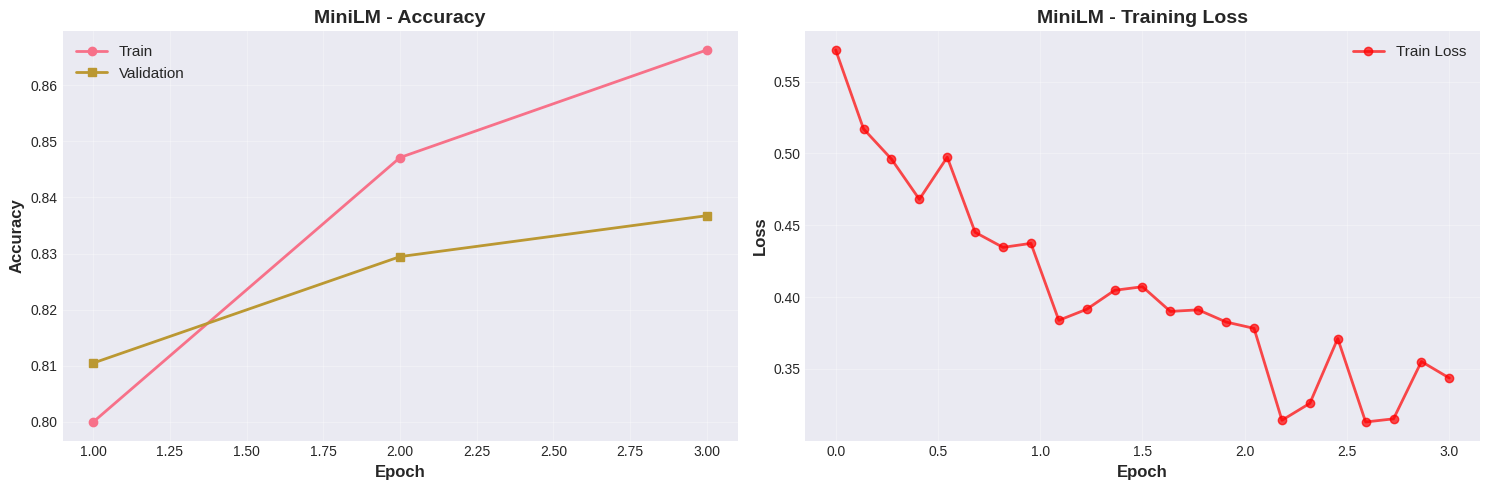


Evaluating on Test Set...



MiniLM - TEST SET RESULTS
Accuracy:  0.8241
F1 Score:  0.8006
Precision: 0.8006
Recall:    0.8006

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.84      0.84      0.84       426
    Disaster       0.80      0.80      0.80       336

    accuracy                           0.82       762
   macro avg       0.82      0.82      0.82       762
weighted avg       0.82      0.82      0.82       762


MiniLM model complete!


In [ ]:
#MiniLM
!pip install -q --upgrade transformers datasets evaluate sentencepiece
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("MiniLM Model Training")
print("="*70)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
train_ds = Dataset.from_dict({"text": list(X_tr), "label": list(y_tr)})
val_ds   = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_ds  = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

print("\nLoading MiniLM tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/MiniLM-L12-H384-uncased")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizing datasets...")
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)
print("✓ Tokenization complete!")

print("\nLoading MiniLM model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/MiniLM-L12-H384-uncased",
    num_labels=2
)
print("✓ Model loaded!")

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./minilm_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("\n" + "="*70)
print("Starting Training...")
print("="*70)

history = trainer.train()

print("\n✓ Training complete!")
print("\nGenerating training graph...")

log_history = trainer.state.log_history
train_loss = []
val_accuracy = []
epochs_list = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
    if 'eval_accuracy' in log:
        val_accuracy.append(log['eval_accuracy'])
        epochs_list.append(log['epoch'])

if len(val_accuracy) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    if len(train_loss) > 0:
        step_size = max(1, len(train_loss) // len(val_accuracy))
        sampled_train_loss = [train_loss[min(i*step_size, len(train_loss)-1)]
                             for i in range(len(val_accuracy))]
        max_loss = max(sampled_train_loss) if sampled_train_loss else 1
        train_acc_approx = [1 - (loss / max_loss) * 0.2 for loss in sampled_train_loss]
        axes[0].plot(epochs_list, train_acc_approx, label='Train',
                    linewidth=2, marker='o')

    axes[0].plot(epochs_list, val_accuracy, label='Validation',
                linewidth=2, marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('MiniLM - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    if len(train_loss) > 0:
        sampled_epochs = np.linspace(0, max(epochs_list), len(train_loss))
        axes[1].plot(sampled_epochs, train_loss, label='Train Loss',
                    linewidth=2, marker='o', color='red', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('MiniLM - Training Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('minilm_training_graph.png', dpi=300, bbox_inches='tight')
    print("✓ Graph saved: minilm_training_graph.png")
    plt.show()

print("\n" + "="*70)
print("Evaluating on Test Set...")
print("="*70)

predictions = trainer.predict(test_ds)
y_pred_minilm = np.argmax(predictions.predictions, axis=1)

accuracy_minilm = accuracy_score(y_test, y_pred_minilm)
f1_minilm = f1_score(y_test, y_pred_minilm, average='binary')
precision_minilm = precision_score(y_test, y_pred_minilm, average='binary')
recall_minilm = recall_score(y_test, y_pred_minilm, average='binary')

print("\n" + "="*70)
print("MiniLM - TEST SET RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy_minilm:.4f}")
print(f"F1 Score:  {f1_minilm:.4f}")
print(f"Precision: {precision_minilm:.4f}")
print(f"Recall:    {recall_minilm:.4f}")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_minilm,
                          target_names=['Not Disaster', 'Disaster']))

print("\nMiniLM model complete!")

Sentence-Transformer + Logistic Regression
Preparing data...
Training samples: 6851
Test samples: 762

Loading Sentence-Transformer model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

✓ Training embeddings shape: (6851, 384)

Encoding test data...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

✓ Test embeddings shape: (762, 384)

Training Logistic Regression Classifier...

✓ Training complete!

Making predictions on test set...
✓ Predictions complete!

Sentence-Transformer + LR - TEST SET RESULTS
Accuracy:  0.8176
F1 Score:  0.7852
Precision: 0.8167
Recall:    0.7560

Classification Report:


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


              precision    recall  f1-score   support

Not Disaster       0.82      0.87      0.84       426
    Disaster       0.82      0.76      0.79       336

    accuracy                           0.82       762
   macro avg       0.82      0.81      0.81       762
weighted avg       0.82      0.82      0.82       762


Generating metrics visualization...
✓ Visualization saved: sentence_transformer_lr_metrics.png


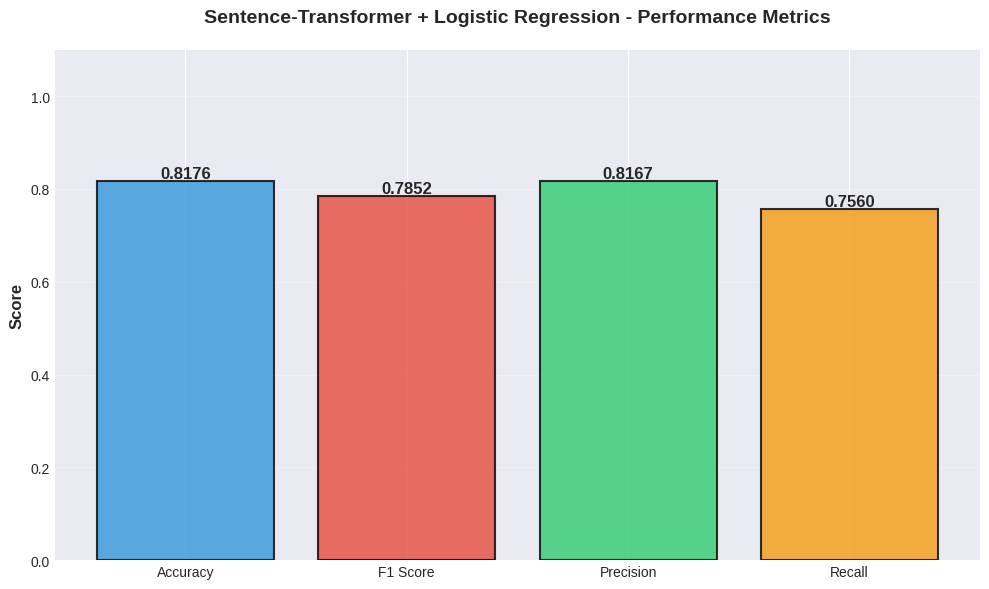


Model Information:
Embedding Model: all-MiniLM-L6-v2
Embedding Dimension: 384
Classifier: Logistic Regression
Number of iterations: 15
Solver: lbfgs

✓ Sentence-Transformer + LR model complete!

Note: This model has no iterative training graph.
Logistic Regression trains in a single step using all embeddings.


In [ ]:
# Sentence-Transformer (MiniLM L6 V2) + Logistic Regression
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("Sentence-Transformer + Logistic Regression")
print("="*70)

print("Preparing data...")
Xtr = list(X_train)
Xte = list(X_test)
ytr = np.array(y_train)
yte = np.array(y_test)

print(f"Training samples: {len(Xtr)}")
print(f"Test samples: {len(Xte)}")

print("\nLoading Sentence-Transformer model (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("✓ Model loaded!")

print("\n" + "="*70)
print("Generating Embeddings...")
print("="*70)

print("\nEncoding training data...")
Xtr_emb = embedder.encode(
    Xtr,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Training embeddings shape: {Xtr_emb.shape}")

print("\nEncoding test data...")
Xte_emb = embedder.encode(
    Xte,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"✓ Test embeddings shape: {Xte_emb.shape}")

print("\n" + "="*70)
print("Training Logistic Regression Classifier...")
print("="*70)

clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    verbose=1
)

clf.fit(Xtr_emb, ytr)
print("\nTraining complete!")

print("\nMaking predictions on test set...")
y_pred_sbert = clf.predict(Xte_emb)
print("Predictions complete!")

accuracy_sbert = accuracy_score(yte, y_pred_sbert)
f1_sbert = f1_score(yte, y_pred_sbert, average='binary')
precision_sbert = precision_score(yte, y_pred_sbert, average='binary')
recall_sbert = recall_score(yte, y_pred_sbert, average='binary')

print("\n" + "="*70)
print("Sentence-Transformer + LR - TEST SET RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy_sbert:.4f}")
print(f"F1 Score:  {f1_sbert:.4f}")
print(f"Precision: {precision_sbert:.4f}")
print(f"Recall:    {recall_sbert:.4f}")
print("="*70)

print("\nClassification Report:")
print(classification_report(yte, y_pred_sbert,
                          target_names=['Not Disaster', 'Disaster']))

print("\nGenerating metrics visualization...")

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
values = [accuracy_sbert, f1_sbert, precision_sbert, recall_sbert]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{value:.4f}',
           ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Sentence-Transformer + Logistic Regression - Performance Metrics',
            fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sentence_transformer_lr_metrics.png', dpi=300, bbox_inches='tight')
print("Visualization saved: sentence_transformer_lr_metrics.png")
plt.show()

print("\n" + "="*70)
print("Model Information:")
print("="*70)
print(f"Embedding Model: all-MiniLM-L6-v2")
print(f"Embedding Dimension: {Xtr_emb.shape[1]}")
print(f"Classifier: Logistic Regression")
print(f"Number of iterations: {clf.n_iter_[0]}")
print(f"Solver: {clf.solver}")
print("="*70)

print("\nSentence-Transformer + LR model complete!")

print("\nNote: This model has no iterative training graph.")
print("Logistic Regression trains in a single step using all embeddings.")

Using device: cuda
Frozen MiniLM + BiLSTM + Attention
Preparing data...
Training samples: 6851
Test samples: 762

Loading tokenizer and encoder: microsoft/MiniLM-L12-H384-uncased
✓ Encoder loaded and frozen!

Splitting data into train and validation sets...
Training samples: 6165
Validation samples: 686

Creating datasets and dataloaders...
✓ Datasets created!

Initializing model...
Total parameters: 526,850
Trainable parameters: 526,850
✓ Model initialized!

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Epoch 1/6
  Train Loss: 0.5170 | Train Acc: 0.7340
  Val Loss:   0.4447 | Val Acc:   0.8120
----------------------------------------------------------------------
Epoch 2/6
  Train Loss: 0.4145 | Train Acc: 0.8154
  Val Loss:   0.4225 | Val Acc:   0.8076
----------------------------------------------------------------------
Epoch 3/6
  Train Loss: 0.3951 | Train Acc: 0.8294
  Val Loss:   0.4172 | Val Acc:   0.8134
----------------------------------------------------------------------
Epoch 4/6
  Train Loss: 0.3861 | Train Acc: 0.8320
  Val Loss:   0.4161 | Val Acc:   0.8207
----------------------------------------------------------------------
Epoch 5/6
  Train Loss: 0.3679 | Train Acc: 0.8440
  Val Loss:   0.4158 | Val Acc:   0.8163
----------------------------------------------------------------------
Epoch 6/6
  Train Loss: 0.3599 | Train Acc: 0.8493
  Val Loss:   0.4268 | Val Acc:   0.8149
----------------------------------------------------------------------

✓ Training complete!


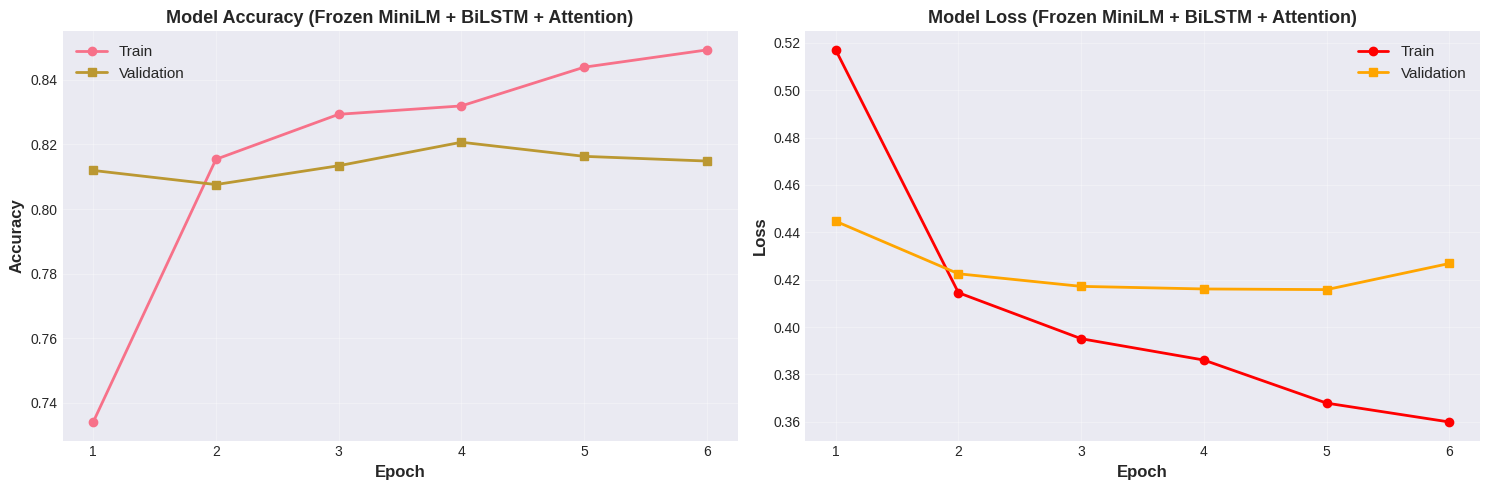


Evaluating on Test Set...

Frozen MiniLM + BiLSTM + Attention - TEST SET RESULTS
Accuracy:  0.8268
F1 Score:  0.7793
Precision: 0.8893
Recall:    0.6935

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.79      0.93      0.86       426
    Disaster       0.89      0.69      0.78       336

    accuracy                           0.83       762
   macro avg       0.84      0.81      0.82       762
weighted avg       0.84      0.83      0.82       762


✓ Frozen MiniLM + BiLSTM + Attention model complete!


In [ ]:
!pip install -q transformers torch sentencepiece

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("="*70)
print("Frozen MiniLM + BiLSTM + Attention")
print("="*70)
print("Preparing data...")
Xtr = list(X_train)
Xte = list(X_test)
ytr = np.array(y_train)
yte = np.array(y_test)

print(f"Training samples: {len(Xtr)}")
print(f"Test samples: {len(Xte)}")

MODEL_NAME = "microsoft/MiniLM-L12-H384-uncased"

print(f"\nLoading tokenizer and encoder: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME)
encoder.to(device)
encoder.eval()  # Set to evaluation mode (frozen)

# Freeze all encoder parameters
for param in encoder.parameters():
    param.requires_grad = False

print("✓ Encoder loaded and frozen!")

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=64,  # Shorter for tweets
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.encodings["input_ids"][idx],
            self.encodings["attention_mask"][idx],
            self.labels[idx]
        )

print("\nSplitting data into train and validation sets...")
Xtr_train, Xtr_val, ytr_train, ytr_val = train_test_split(
    Xtr, ytr, test_size=0.1, random_state=42, stratify=ytr
)

print(f"Training samples: {len(Xtr_train)}")
print(f"Validation samples: {len(Xtr_val)}")
print("\nCreating datasets and dataloaders...")
train_dataset = TweetDataset(Xtr_train, ytr_train)
val_dataset = TweetDataset(Xtr_val, ytr_val)
test_dataset = TweetDataset(Xte, yte)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("✓ Datasets created!")

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output, attention_mask):
        # lstm_output: (batch_size, seq_len, hidden_dim)
        # attention_mask: (batch_size, seq_len)

        # Calculate attention scores
        scores = self.attention(lstm_output).squeeze(-1)  # (batch_size, seq_len)

        # Mask padding tokens
        scores = scores.masked_fill(attention_mask == 0, -1e9)

        # Calculate attention weights
        weights = torch.softmax(scores, dim=1)  # (batch_size, seq_len)

        # Apply attention weights
        weighted_output = (lstm_output * weights.unsqueeze(-1)).sum(dim=1)

        return weighted_output

class MiniLMBiLSTMAttention(nn.Module):
    def __init__(self, encoder_dim=384, lstm_hidden=128, dropout=0.4):
        super().__init__()

        # BiLSTM layer
        self.lstm = nn.LSTM(
            input_size=encoder_dim,
            hidden_size=lstm_hidden,
            bidirectional=True,
            batch_first=True,
            dropout=0.1
        )

        # Attention layer
        self.attention = Attention(lstm_hidden * 2)  # *2 for bidirectional

        # Dropout and output layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden * 2, 1)

    def forward(self, input_ids, attention_mask):
        # Get frozen embeddings from MiniLM
        with torch.no_grad():
            embeddings = encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state  # (batch_size, seq_len, 384)

        # BiLSTM
        lstm_output, _ = self.lstm(embeddings)  # (batch_size, seq_len, 256)

        # Attention pooling
        pooled = self.attention(lstm_output, attention_mask)  # (batch_size, 256)

        # Dropout and classification
        pooled = self.dropout(pooled)
        output = torch.sigmoid(self.fc(pooled)).squeeze(-1)

        return output

print("\nInitializing model...")
model = MiniLMBiLSTMAttention().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("✓ Model initialized!")

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

EPOCHS = 6
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

print("\n" + "="*70)
print("Starting Training...")
print("="*70)

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_correct = 0
    train_total = 0
    train_losses = []

    for input_ids, attention_mask, labels in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Calculate accuracy
        predictions = (outputs >= 0.5).float()
        train_total += labels.size(0)
        train_correct += (predictions == labels).sum().item()

    train_acc = train_correct / train_total
    train_loss = np.mean(train_losses)
    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0
    val_losses = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_losses.append(loss.item())

            predictions = (outputs >= 0.5).float()
            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    val_acc = val_correct / val_total
    val_loss = np.mean(val_losses)
    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 70)

print("\nTraining complete!")

print("\nGenerating training graphs...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, train_acc_history, label='Train',
            linewidth=2, marker='o')
axes[0].plot(epochs_range, val_acc_history, label='Validation',
            linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy (Frozen MiniLM + BiLSTM + Attention)',
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, train_loss_history, label='Train',
            linewidth=2, marker='o', color='red')
axes[1].plot(epochs_range, val_loss_history, label='Validation',
            linewidth=2, marker='s', color='orange')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss (Frozen MiniLM + BiLSTM + Attention)',
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('frozen_minilm_bilstm_attention_training_graph.png',
           dpi=300, bbox_inches='tight')
print("✓ Graph saved: frozen_minilm_bilstm_attention_training_graph.png")
plt.show()
print("\n" + "="*70)
print("Evaluating on Test Set...")
print("="*70)

model.eval()
y_pred_frozen = []
y_true = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids, attention_mask)
        predictions = (outputs.cpu().numpy() >= 0.5).astype(int)

        y_pred_frozen.extend(predictions)
        y_true.extend(labels.numpy())

y_pred_frozen = np.array(y_pred_frozen)
y_true = np.array(y_true)

# Calculate metrics
accuracy_frozen = accuracy_score(y_true, y_pred_frozen)
f1_frozen = f1_score(y_true, y_pred_frozen, average='binary')
precision_frozen = precision_score(y_true, y_pred_frozen, average='binary')
recall_frozen = recall_score(y_true, y_pred_frozen, average='binary')

print("\n" + "="*70)
print("Frozen MiniLM + BiLSTM + Attention - TEST SET RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy_frozen:.4f}")
print(f"F1 Score:  {f1_frozen:.4f}")
print(f"Precision: {precision_frozen:.4f}")
print(f"Recall:    {recall_frozen:.4f}")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_frozen,
                          target_names=['Not Disaster', 'Disaster']))

print("\nFrozen MiniLM + BiLSTM + Attention model complete!")

Generating Confusion Matrices

Checking available models...
  ✓ DistilBERT
  ✓ ALBERT
  ✓ MiniLM
  ✓ Sentence-BERT + LR
  ✓ Frozen MiniLM + BiLSTM

Found 5 trained models

✓ Saved: all_models_confusion_matrices.png


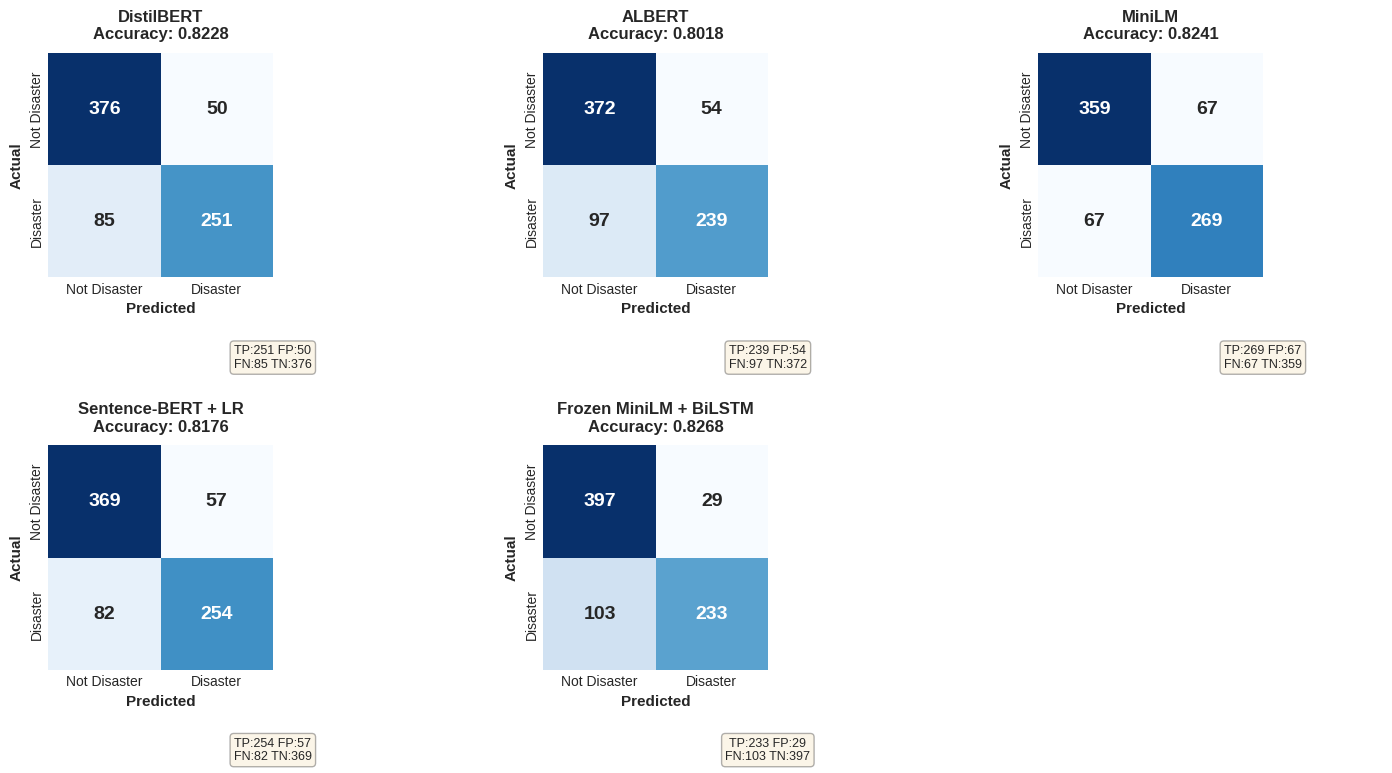


Generating individual matrices...

Text-based confusion matrices:

DistilBERT:
Accuracy: 0.8228
                  Predicted
                  0      1
Actual    0    [ 376] [  50]
          1    [  85] [ 251]
TP: 251  FP: 50  FN: 85  TN: 376

ALBERT:
Accuracy: 0.8018
                  Predicted
                  0      1
Actual    0    [ 372] [  54]
          1    [  97] [ 239]
TP: 239  FP: 54  FN: 97  TN: 372

MiniLM:
Accuracy: 0.8241
                  Predicted
                  0      1
Actual    0    [ 359] [  67]
          1    [  67] [ 269]
TP: 269  FP: 67  FN: 67  TN: 359

Sentence-BERT + LR:
Accuracy: 0.8176
                  Predicted
                  0      1
Actual    0    [ 369] [  57]
          1    [  82] [ 254]
TP: 254  FP: 57  FN: 82  TN: 369

Frozen MiniLM + BiLSTM:
Accuracy: 0.8268
                  Predicted
                  0      1
Actual    0    [ 397] [  29]
          1    [ 103] [ 233]
TP: 233  FP: 29  FN: 103  TN: 397

Generated confusion matrices for 5 mode

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

print("="*70)
print("Generating Confusion Matrices")
print("="*70)

all_models = {
    'BiLSTM': 'y_pred',
    'BiGRU': 'y_pred_gru',
    'TextCNN': 'y_pred_cnn',
    'TF-IDF + LR': 'y_pred_lr',
    'DistilBERT': 'y_pred_distilbert',
    'ALBERT': 'y_pred_albert',
    'MiniLM': 'y_pred_minilm',
    'Sentence-BERT + LR': 'y_pred_sbert',
    'Frozen MiniLM + BiLSTM': 'y_pred_frozen'
}

available_models = {}
missing_models = []

print("\nChecking available models...")
for model_name, pred_var in all_models.items():
    if pred_var in globals():
        available_models[model_name] = globals()[pred_var]
        print(f"  ✓ {model_name}")
    else:
        missing_models.append(model_name)

print(f"\nFound {len(available_models)} trained models")

if len(available_models) == 0:
    raise ValueError("No predictions found. Please train at least one model first.")

if 'y_test' not in globals():
    raise ValueError("y_test not found. Please run data split first.")

n_models = len(available_models)
if n_models <= 3:
    n_cols = n_models
    n_rows = 1
elif n_models <= 6:
    n_cols = 3
    n_rows = 2
else:
    n_cols = 3
    n_rows = (n_models + 2) // 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))

if n_models == 1:
    axes = [axes]
elif n_rows == 1 or n_cols == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for idx, (model_name, predictions) in enumerate(available_models.items()):
    ax = axes[idx]

    if len(predictions.shape) > 1:
        predictions = predictions.flatten()

    cm = confusion_matrix(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                square=True, annot_kws={'size': 14, 'weight': 'bold'})

    ax.set_title(f'{model_name}\nAccuracy: {accuracy:.4f}',
                fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Not Disaster', 'Disaster'], fontsize=10)
    ax.set_yticklabels(['Not Disaster', 'Disaster'], fontsize=10)

    tn, fp, fn, tp = cm.ravel()
    metrics_text = f'TP:{tp} FP:{fp}\nFN:{fn} TN:{tn}'
    ax.text(1, -0.3, metrics_text, transform=ax.transAxes,
           fontsize=9, ha='center', va='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: all_models_confusion_matrices.png")
plt.show()

print("\nGenerating individual matrices...")
for model_name, predictions in available_models.items():
    if len(predictions.shape) > 1:
        predictions = predictions.flatten()

    cm = confusion_matrix(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                square=True, annot_kws={'size': 16, 'weight': 'bold'})

    ax.set_title(f'{model_name} - Confusion Matrix\nAccuracy: {accuracy:.4f}',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], fontsize=11)
    ax.set_yticklabels(['Not Disaster (0)', 'Disaster (1)'], fontsize=11)

    tn, fp, fn, tp = cm.ravel()
    metrics_text = f'TP: {tp}  FP: {fp}  FN: {fn}  TN: {tn}'
    plt.figtext(0.5, -0.05, metrics_text, ha='center', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    plt.tight_layout()

    safe_name = model_name.replace(' ', '_').replace('+', 'plus').lower()
    filename = f'confusion_matrix_{safe_name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

print("\nText-based confusion matrices:")
print("="*70)

for model_name, predictions in available_models.items():
    if len(predictions.shape) > 1:
        predictions = predictions.flatten()

    cm = confusion_matrix(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"                  Predicted")
    print(f"                  0      1")
    print(f"Actual    0    [{tn:4d}] [{fp:4d}]")
    print(f"          1    [{fn:4d}] [{tp:4d}]")
    print(f"TP: {tp}  FP: {fp}  FN: {fn}  TN: {tn}")

print("\n" + "="*70)
print(f"Generated confusion matrices for {len(available_models)} models")
print("="*70)